# Experiment 4 — Is large-`N` recovery limited by primitive exposure?

The completed five-seed sweep in Experiment 3 held the total SAE training budget fixed at
`T = 128M` examples. Because every example contains one uniformly selected `x`
primitive and one uniformly selected `y` primitive, the expected number of
training examples containing each named primitive is

$$K = \frac{T}{N}. $$

The nearly perfect `N=8` condition had `K = 128M / 8 = 16M`, whereas the
declining `N=256` condition had only `K = 128M / 256 = 0.5M`. This notebook
holds `N=256` fixed and increases `K`. The primary test gives `N=256` the same
`K=16M` exposure as `N=8`, requiring `T=4.096B` generated examples. Higher
values `K=24M` and `K=32M` test whether still more training restores true-feature recovery.


## What this experiment can establish

- If `N=256` recovery approaches the `N=8` reference at `K=16M`, the original
  decline was substantially caused by insufficient training exposure per primitive.
- If recovery improves only above `K=16M`, larger SAEs require more exposure per
  primitive than the small successful model.
- If recovery plateaus well below the reference even at larger `K`, additional
  training budget alone does not explain the large-`N` decline.

**Scope limitation:** increasing `K` increases both fresh generated samples and
optimizer steps. It therefore tests total training exposure, not unique-data budget
and optimization steps separately. A later control would compare fresh samples
against repeated passes over a fixed activation buffer at the same step count.

Matching `K` also does not match exposure per composed pair. Under independent
uniform sampling, an individual pair occurs `T/N² = K/N` times on average. At
`K=16M`, this is 2M occurrences per pair for `N=8` but only 62,500 for `N=256`.


## Environment setup (local or Google Colab)

Run the next cell before any imports. Locally, it finds the existing checkout and performs no clone, pull, or package installation. In Google Colab, it clones the GitHub repository when absent, safely fast-forwards a clean existing clone when enabled, and installs `requirements.txt`.

For long Colab runs, set `USE_GOOGLE_DRIVE=True` so the repository, Experiment 4C results, and resumable checkpoints live beneath `MyDrive/SAE`. `UPDATE_EXISTING_COLAB_REPOSITORY=True` updates a clean existing clone with `git pull --ff-only`; a clone with local changes is preserved and the pull is skipped.


In [2]:
from __future__ import annotations

import importlib.util
import os
import subprocess
import sys
from pathlib import Path


IN_COLAB = importlib.util.find_spec('google.colab') is not None
USE_GOOGLE_DRIVE = True  # Persist the long Experiment 4C GPU run.
INSTALL_REQUIREMENTS = IN_COLAB
UPDATE_EXISTING_COLAB_REPOSITORY = True
COLAB_REPOSITORY_URL = 'https://github.com/Adefioye/SAE.git'


def find_experiment_dir(start: Path) -> Path | None:
    candidates = (start, start / 'composed-features')
    return next(
        (path for path in candidates
         if (path / 'sparse_factorial_generator.py').is_file()),
        None,
    )


if IN_COLAB:
    if USE_GOOGLE_DRIVE:
        from google.colab import drive

        drive.mount('/content/drive')
        repository_root = Path('/content/drive/MyDrive/SAE-CHECKPOINTS')
    else:
        repository_root = Path('/content/SAE')

    EXPERIMENT_DIR = find_experiment_dir(repository_root)
    if EXPERIMENT_DIR is None:
        if repository_root.exists() and any(repository_root.iterdir()):
            raise FileExistsError(
                f'{repository_root} exists but is not the SAE repository. '
                'Choose another path or move that directory.'
            )
        repository_root.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(
            [
                'git', 'clone', '--depth', '1',
                COLAB_REPOSITORY_URL, str(repository_root),
            ],
            check=True,
        )
    elif UPDATE_EXISTING_COLAB_REPOSITORY:
        git_directory = repository_root / '.git'
        if git_directory.is_dir():
            status = subprocess.run(
                ['git', '-C', str(repository_root), 'status', '--porcelain'],
                check=True, capture_output=True, text=True,
            ).stdout.strip()
            if status:
                print('Existing Colab clone has local changes; skipping pull.')
            else:
                subprocess.run(
                    ['git', '-C', str(repository_root), 'pull', '--ff-only'],
                    check=True,
                )
        else:
            print('Existing project is not a Git clone; skipping pull.')
    EXPERIMENT_DIR = find_experiment_dir(repository_root)
else:
    EXPERIMENT_DIR = find_experiment_dir(Path.cwd().resolve())

if EXPERIMENT_DIR is None:
    raise FileNotFoundError(
        'Could not find composed-features/sparse_factorial_generator.py. '
        'Run locally from the repository root/composed-features directory, '
        'or verify the Colab repository URL.'
    )

EXPERIMENT_DIR = EXPERIMENT_DIR.resolve()
REQUIREMENTS_PATH = EXPERIMENT_DIR / 'requirements.txt'
if not REQUIREMENTS_PATH.is_file():
    raise FileNotFoundError(f'Missing requirements file: {REQUIREMENTS_PATH}')

if INSTALL_REQUIREMENTS:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install',
        '--upgrade-strategy', 'only-if-needed',
        '-r', str(REQUIREMENTS_PATH),
    ])

os.chdir(EXPERIMENT_DIR)
print('Runtime:', 'Google Colab' if IN_COLAB else 'local Jupyter')
print('Experiment directory:', EXPERIMENT_DIR)
print('Requirements installed:', INSTALL_REQUIREMENTS)
print('Persistent Colab storage:', IN_COLAB and USE_GOOGLE_DRIVE)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Runtime: Google Colab
Experiment directory: /content/drive/MyDrive/SAE-CHECKPOINTS/composed-features
Requirements installed: True
Persistent Colab storage: True


In [3]:
import json
import sys
from collections.abc import Iterator, Sequence
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from tqdm.auto import tqdm


if 'EXPERIMENT_DIR' not in globals():
    WORKING_DIR = Path.cwd().resolve()
    if (WORKING_DIR / 'sparse_factorial_generator.py').is_file():
        EXPERIMENT_DIR = WORKING_DIR
    elif (WORKING_DIR / 'composed-features' / 'sparse_factorial_generator.py').is_file():
        EXPERIMENT_DIR = WORKING_DIR / 'composed-features'
    else:
        raise FileNotFoundError(
            'Run the Environment setup cell before this import cell.'
        )
EXPERIMENT_DIR = Path(EXPERIMENT_DIR).resolve()

if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

from sae_lens import StandardTrainingSAE, StandardTrainingSAEConfig
from sae_lens.config import LoggingConfig, SAETrainerConfig
from sae_lens.training.sae_trainer import SAETrainer

from sparse_factorial_generator import FactorialConfig, SparseFactorialGenerator
from toy_model import default_device


DEVICE = default_device()
if IN_COLAB and DEVICE.type != 'cuda':
    raise RuntimeError(
        'Experiment 4C requires a Colab GPU. Select Runtime > Change '
        'runtime type > GPU, then reconnect and rerun from the top.'
    )
ARTIFACT_ROOT = EXPERIMENT_DIR / 'artifacts' / '04_fixed_primitive_exposure'
CHECKPOINT_ROOT = ARTIFACT_ROOT / 'sae_trajectories'
RESULTS_ROOT = ARTIFACT_ROOT / 'results'
REFERENCE_PATH = (
    EXPERIMENT_DIR
    / 'artifacts'
    / '03_sparse_factorial_antipodal'
    / 'results'
    / 'n_primitive_recovery_128m_5_sae_seeds_aggregate.csv'
)
for path in (CHECKPOINT_ROOT, RESULTS_ROOT):
    path.mkdir(parents=True, exist_ok=True)


def load_n8_reference() -> pd.Series:
    if REFERENCE_PATH.is_file():
        reference_frame = pd.read_csv(REFERENCE_PATH)
        matches = reference_frame.loc[reference_frame['n_per_set'] == 8]
        if len(matches) != 1:
            raise ValueError(
                f'Expected exactly one N=8 row in {REFERENCE_PATH}.'
            )
        return matches.iloc[0]

    print(
        'Experiment 3 reference CSV is absent; using the recorded N=8 '
        'five-seed means embedded in this notebook.'
    )
    return pd.Series({
        'n_per_set': 8,
        'n_sae_seeds': 5,
        'hungarian_90_mean': 0.9625,
        'mmcs_mean': 0.9916242003440857,
    })


print('Experiment directory:', EXPERIMENT_DIR)
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('CUDA device:', torch.cuda.get_device_name(DEVICE))
print('Artifact root:', ARTIFACT_ROOT)


Experiment directory: /content/drive/MyDrive/SAE-CHECKPOINTS/composed-features
Device: cuda
CUDA device: NVIDIA L4
Artifact root: /content/drive/MyDrive/SAE-CHECKPOINTS/composed-features/artifacts/04_fixed_primitive_exposure


## Experimental constants and exposure milestones

The full experiment keeps the Experiment 3 setup fixed: `N=256`, activation
dimension 256, 512 SAE latents, uniform independent feature identities, perfectly
correlated pair amplitudes, no singleton examples, and SAE seed 0. Experiment 3
showed very small seed-to-seed variance at `N=256`, so this experiment uses one
trajectory to concentrate compute on substantially larger training budgets.

Milestones are evaluated along one continuous training trajectory. The curve starts
at half the successful `N=8` exposure and reaches twice that exposure. Checkpoints
contain SAE weights, optimizer
state, scheduler state, and generator RNG state, so interrupted runs can resume.


In [4]:
N_PER_SET = 256
ACTIVATION_DIM = 256
D_SAE = 2 * N_PER_SET
TRAIN_BATCH_SIZE = 16_384
LEARNING_RATE = 3e-4
L1_COEFFICIENT = 0.3
ADAM_BETA1 = 0.0
ADAM_BETA2 = 0.999
DICTIONARY_SEED = 0
DATA_SEED = 0
SAE_SEED = 0
EVAL_SEED = 10_000
EVAL_SAMPLES = 65_536

# K is the expected number of training examples containing each named primitive.
K_VALUES = (8_000_000, 16_000_000, 24_000_000, 32_000_000)

# The full run is extremely expensive. QUICK_MODE only checks the pipeline.
QUICK_MODE = False
QUICK_K_VALUES = (4_000, 8_000)

if QUICK_MODE:
    ACTIVE_K_VALUES = QUICK_K_VALUES
else:
    ACTIVE_K_VALUES = K_VALUES

assert tuple(sorted(set(ACTIVE_K_VALUES))) == ACTIVE_K_VALUES
for k in ACTIVE_K_VALUES:
    assert (k * N_PER_SET) % TRAIN_BATCH_SIZE == 0

print('Quick mode:', QUICK_MODE)
print('SAE seed:', SAE_SEED)
print('K milestones:', ACTIVE_K_VALUES)


Quick mode: False
SAE seed: 0
K milestones: (8000000, 16000000, 24000000, 32000000)


In [5]:
budget_table = pd.DataFrame(
    {
        'K_expected_samples_per_primitive': ACTIVE_K_VALUES,
        'training_samples_T': [k * N_PER_SET for k in ACTIVE_K_VALUES],
        'optimizer_steps': [
            k * N_PER_SET // TRAIN_BATCH_SIZE for k in ACTIVE_K_VALUES
        ],
        'expected_samples_per_pair': [
            k / N_PER_SET for k in ACTIVE_K_VALUES
        ],
        'relative_to_N8_K': [k / 16_000_000 for k in ACTIVE_K_VALUES],
    }
)
display(budget_table.style.format({
    'K_expected_samples_per_primitive': '{:,.0f}',
    'training_samples_T': '{:,.0f}',
    'optimizer_steps': '{:,.0f}',
    'expected_samples_per_pair': '{:,.1f}',
    'relative_to_N8_K': '{:.3g}×',
}))

# Exact full-run mapping for N=256:
# K=8M  -> T=2.048B samples -> 2,000,000 optimizer steps
# K=16M -> T=4.096B samples -> 4,000,000 optimizer steps
# K=24M -> T=6.144B samples -> 6,000,000 optimizer steps
# K=32M -> T=8.192B samples -> 8,000,000 optimizer steps

max_samples_per_seed = max(ACTIVE_K_VALUES) * N_PER_SET
max_steps_per_seed = max_samples_per_seed // TRAIN_BATCH_SIZE
print(f'Maximum samples in the trajectory: {max_samples_per_seed:,}')
print(f'Maximum optimizer steps in the trajectory: {max_steps_per_seed:,}')
print('This is the total for the single SAE trajectory.')


,K_expected_samples_per_primitive,training_samples_T,optimizer_steps,expected_samples_per_pair,relative_to_N8_K
0,"8,000,000","2,048,000,000","125,000","31,250.0",0.5×
1,"16,000,000","4,096,000,000","250,000","62,500.0",1×
2,"24,000,000","6,144,000,000","375,000","93,750.0",1.5×
3,"32,000,000","8,192,000,000","500,000","125,000.0",2×


Maximum samples in the trajectory: 8,192,000,000
Maximum optimizer steps in the trajectory: 500,000
This is the total for the single SAE trajectory.


## Fixed `N=256` antipodal data generator

This reproduces the Experiment 3 `N=256` dictionary exactly for dictionary seed 0.
Each factor set contains 128 antipodal axis pairs. The `x` and `y` axes occupy
orthogonal subspaces before a random orthogonal rotation. Every generated example
contains exactly one uniformly sampled `x` primitive and one uniformly sampled `y`
primitive with a shared amplitude.


In [6]:
def orthogonal_matrix(dim: int, seed: int) -> torch.Tensor:
    generator = torch.Generator(device='cpu').manual_seed(seed)
    matrix = torch.randn(dim, dim, generator=generator)
    q, r = torch.linalg.qr(matrix)
    signs = torch.where(torch.diag(r) >= 0, 1.0, -1.0)
    return q * signs.unsqueeze(0)


def make_antipodal_dictionary(
    n_per_set: int,
    *,
    seed: int,
    device: torch.device | str,
) -> torch.Tensor:
    if n_per_set <= 0 or n_per_set % 2:
        raise ValueError('Antipodal geometry requires a positive, even N.')

    half = n_per_set // 2
    dictionary = torch.zeros(2 * n_per_set, n_per_set)
    for axis in range(half):
        dictionary[2 * axis, axis] = 1.0
        dictionary[2 * axis + 1, axis] = -1.0

        y_offset = n_per_set
        y_axis = half + axis
        dictionary[y_offset + 2 * axis, y_axis] = 1.0
        dictionary[y_offset + 2 * axis + 1, y_axis] = -1.0

    return (dictionary @ orthogonal_matrix(n_per_set, seed)).to(device)


TRUE_DICTIONARY = make_antipodal_dictionary(
    N_PER_SET, seed=DICTIONARY_SEED, device=DEVICE
)


def build_generator(seed: int) -> SparseFactorialGenerator:
    return SparseFactorialGenerator(
        FactorialConfig(
            n_x=N_PER_SET,
            n_y=N_PER_SET,
            activation_dim=ACTIVATION_DIM,
            amplitude_correlation=1.0,
            singleton_probability=0.0,
            noise_std=0.0,
            seed=seed,
        ),
        device=str(DEVICE),
        true_dictionary=TRUE_DICTIONARY,
        normalize_dictionary=False,
    )


class SparseFactorialActivationIterator(Iterator[torch.Tensor]):
    def __init__(self, generator: SparseFactorialGenerator, batch_size: int):
        self.generator = generator
        self.batch_size = batch_size

    def __iter__(self):
        return self

    @torch.no_grad()
    def __next__(self) -> torch.Tensor:
        hidden, _ = self.generator.sample(self.batch_size)
        return hidden.detach()


unit_dictionary = F.normalize(TRUE_DICTIONARY, dim=1)
x_dictionary = unit_dictionary[:N_PER_SET]
y_dictionary = unit_dictionary[N_PER_SET:]
assert torch.allclose(x_dictionary[0::2], -x_dictionary[1::2], atol=2e-5)
assert torch.allclose(y_dictionary[0::2], -y_dictionary[1::2], atol=2e-5)
assert float((x_dictionary @ y_dictionary.T).abs().max()) < 2e-5
print('Verified fixed N=256 orthogonal-antipodal dictionary.')


Verified fixed N=256 orthogonal-antipodal dictionary.


## SAE and resumable trajectory training

All milestones for a seed belong to one continuous optimizer trajectory. This is a
paired learning-curve experiment: the decoder evaluated at a larger `K` is the same
SAE after additional training, not a new initialization. Different SAE seeds provide
independent trajectories.


In [7]:
def make_standard_sae(sae_seed: int) -> StandardTrainingSAE:
    torch.manual_seed(sae_seed)
    cfg = StandardTrainingSAEConfig(
        d_in=ACTIVATION_DIM,
        d_sae=D_SAE,
        device=str(DEVICE),
        dtype='float32',
        apply_b_dec_to_input=False,
        normalize_activations='none',
        l1_coefficient=L1_COEFFICIENT,
        lp_norm=1.0,
        l1_warm_up_steps=0,
        decoder_init_norm=1.0,
    )
    return StandardTrainingSAE(cfg).to(DEVICE)


def make_trainer(
    sae: StandardTrainingSAE,
    generator: SparseFactorialGenerator,
    *,
    total_training_samples: int,
) -> SAETrainer:
    cfg = SAETrainerConfig(
        total_training_samples=total_training_samples,
        train_batch_size_samples=TRAIN_BATCH_SIZE,
        lr=LEARNING_RATE,
        lr_end=LEARNING_RATE,
        lr_scheduler_name='constant',
        lr_warm_up_steps=0,
        lr_decay_steps=0,
        adam_beta1=ADAM_BETA1,
        adam_beta2=ADAM_BETA2,
        device=str(DEVICE),
        n_checkpoints=0,
        checkpoint_path=None,
        save_final_checkpoint=False,
        logger=LoggingConfig(
            log_to_wandb=False,
            eval_every_n_wandb_logs=2**31 - 1,
        ),
        n_batches_for_norm_estimate=1,
    )
    return SAETrainer(
        cfg=cfg,
        sae=sae,
        data_provider=SparseFactorialActivationIterator(
            generator, TRAIN_BATCH_SIZE
        ),
    )


def milestone_name(k: int) -> str:
    total = k * N_PER_SET
    return f'K{k:012d}__T{total:015d}'


def seed_checkpoint_root(sae_seed: int) -> Path:
    return CHECKPOINT_ROOT / f'N{N_PER_SET:04d}__sae-{sae_seed}'


def milestone_path(sae_seed: int, k: int) -> Path:
    return seed_checkpoint_root(sae_seed) / milestone_name(k)


def checkpoint_is_resumable(path: Path) -> bool:
    required = (
        'cfg.json',
        'sae_weights.safetensors',
        'trainer_state.pt',
        'activation_scaler.json',
        'generator_rng_state.pt',
    )
    return all((path / name).exists() for name in required)


def save_milestone(
    trainer: SAETrainer,
    generator: SparseFactorialGenerator,
    *,
    sae_seed: int,
    k: int,
) -> Path:
    root = seed_checkpoint_root(sae_seed)
    root.mkdir(parents=True, exist_ok=True)
    name = milestone_name(k)
    trainer.save_checkpoint(checkpoint_name=name, base_path=root)
    path = root / name
    torch.save(generator.rng.get_state(), path / 'generator_rng_state.pt')
    metadata = {
        'n_per_set': N_PER_SET,
        'activation_dim': ACTIVATION_DIM,
        'd_sae': D_SAE,
        'sae_seed': sae_seed,
        'dictionary_seed': DICTIONARY_SEED,
        'data_seed': DATA_SEED,
        'k_expected_samples_per_primitive': k,
        'training_samples': k * N_PER_SET,
        'training_steps': trainer.n_training_steps,
        'batch_size': TRAIN_BATCH_SIZE,
        'lr': LEARNING_RATE,
        'l1_coefficient': L1_COEFFICIENT,
    }
    (path / 'experiment_spec.json').write_text(
        json.dumps(metadata, indent=2) + '\n'
    )
    return path


def initialize_or_resume_trajectory(
    sae_seed: int,
    k_values: Sequence[int],
) -> tuple[SAETrainer, SparseFactorialGenerator, int | None]:
    generator = build_generator(DATA_SEED)
    completed_k = [
        k for k in k_values if checkpoint_is_resumable(milestone_path(sae_seed, k))
    ]
    latest_k = max(completed_k, default=None)
    max_total = max(k_values) * N_PER_SET

    if latest_k is None:
        sae = make_standard_sae(sae_seed)
        trainer = make_trainer(
            sae, generator, total_training_samples=max_total
        )
        return trainer, generator, None

    checkpoint = milestone_path(sae_seed, latest_k)
    sae = StandardTrainingSAE.load_from_disk(
        checkpoint, device=str(DEVICE), dtype='float32'
    ).to(DEVICE)
    trainer = make_trainer(sae, generator, total_training_samples=max_total)
    trainer.load_trainer_state(checkpoint)
    generator_state = torch.load(
        checkpoint / 'generator_rng_state.pt', map_location='cpu'
    )
    generator.rng.set_state(generator_state)
    expected_samples = latest_k * N_PER_SET
    if trainer.n_training_samples != expected_samples:
        raise ValueError(
            f'Resumed {trainer.n_training_samples:,} samples; '
            f'expected {expected_samples:,}.'
        )
    return trainer, generator, latest_k


def ensure_seed_trajectory(sae_seed: int, k_values: Sequence[int]) -> None:
    trainer, generator, latest_k = initialize_or_resume_trajectory(
        sae_seed, k_values
    )
    pending = [k for k in k_values if latest_k is None or k > latest_k]
    if not pending:
        print(f'SAE seed {sae_seed}: all milestones already complete.')
        return

    pbar = tqdm(
        total=max(k_values) * N_PER_SET,
        initial=trainer.n_training_samples,
        desc=f'SAE seed {sae_seed}',
    )
    for k in pending:
        target_samples = k * N_PER_SET
        while trainer.n_training_samples < target_samples:
            trainer.maybe_reset_sparsity()
            trainer.step(next(trainer.data_provider))
            trainer.n_training_steps += 1
            pbar.update(TRAIN_BATCH_SIZE)
        if trainer.n_training_samples != target_samples:
            raise RuntimeError('A K milestone was not batch-aligned.')
        path = save_milestone(
            trainer, generator, sae_seed=sae_seed, k=k
        )
        print(f'\nSaved K={k:,}: {path}')
    pbar.close()

    del trainer
    if DEVICE.type == 'mps':
        torch.mps.empty_cache()
    elif DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


## Recovery and training-quality metrics

The primary outcomes match Experiment 3: one-to-one Hungarian primitive recovery
at cosine 0.90 and MMCS. The notebook also records evaluation FVU, mean SAE `L0`,
and the fraction of latents that never activate on
the fresh evaluation batch. High reconstruction quality with persistently poor
primitive recovery would indicate an alternative learned dictionary rather than
simple failure to fit the activation distribution.


In [8]:
@torch.no_grad()
def primitive_recovery_metrics(
    sae: StandardTrainingSAE, dictionary: torch.Tensor
) -> dict[str, float]:
    decoder = F.normalize(sae.W_dec.detach().float(), dim=1)
    primitives = F.normalize(dictionary.detach().float(), dim=1)
    similarity = primitives @ decoder.T

    mmcs = float(similarity.max(dim=1).values.mean())
    primitive_rows, decoder_cols = linear_sum_assignment(
        -similarity.detach().cpu().numpy()
    )
    assigned = similarity[
        torch.as_tensor(primitive_rows, device=similarity.device),
        torch.as_tensor(decoder_cols, device=similarity.device),
    ]
    return {
        'hungarian_90': float((assigned >= 0.90).float().mean()),
        'mmcs': mmcs,
        'hungarian_assigned_cosine_mean': float(assigned.mean()),
        'hungarian_assigned_cosine_min': float(assigned.min()),
    }


@torch.no_grad()
def training_quality_metrics(sae: StandardTrainingSAE) -> dict[str, float]:
    evaluation_generator = build_generator(EVAL_SEED)
    hidden, _ = evaluation_generator.sample(EVAL_SAMPLES)
    feature_acts = sae.encode(hidden)
    reconstructed = sae.decode(feature_acts)

    squared_error = (hidden - reconstructed).pow(2).sum()
    total_variance = (hidden - hidden.mean(dim=0)).pow(2).sum()
    fired = feature_acts > 0
    return {
        'eval_fvu': float(squared_error / total_variance),
        'eval_mean_l0': float(fired.sum(dim=1).float().mean()),
        'eval_mean_l1': float(feature_acts.abs().sum(dim=1).mean()),
        'eval_dead_latent_fraction': float((~fired.any(dim=0)).float().mean()),
    }


RESULT_COLUMNS = [
    'n_per_set',
    'sae_seed',
    'dictionary_seed',
    'data_seed',
    'k_expected_samples_per_primitive',
    'training_samples',
    'optimizer_steps',
    'expected_samples_per_pair',
    'hungarian_90',
    'mmcs',
    'hungarian_assigned_cosine_mean',
    'hungarian_assigned_cosine_min',
    'eval_fvu',
    'eval_mean_l0',
    'eval_mean_l1',
    'eval_dead_latent_fraction',
]


def evaluate_saved_milestones(
    sae_seeds: Sequence[int],
    k_values: Sequence[int],
    output_path: Path,
) -> pd.DataFrame:
    rows = []
    for sae_seed in sae_seeds:
        for k in k_values:
            checkpoint = milestone_path(sae_seed, k)
            if not checkpoint_is_resumable(checkpoint):
                raise FileNotFoundError(f'Incomplete checkpoint: {checkpoint}')
            sae = StandardTrainingSAE.load_from_disk(
                checkpoint, device=str(DEVICE), dtype='float32'
            ).to(DEVICE)
            row = {
                'n_per_set': N_PER_SET,
                'sae_seed': sae_seed,
                'dictionary_seed': DICTIONARY_SEED,
                'data_seed': DATA_SEED,
                'k_expected_samples_per_primitive': k,
                'training_samples': k * N_PER_SET,
                'optimizer_steps': k * N_PER_SET // TRAIN_BATCH_SIZE,
                'expected_samples_per_pair': k / N_PER_SET,
                **primitive_recovery_metrics(sae, TRUE_DICTIONARY),
                **training_quality_metrics(sae),
            }
            rows.append(row)
            pd.DataFrame(rows)[RESULT_COLUMNS].to_csv(output_path, index=False)
            print(
                f'Evaluated seed={sae_seed}, K={k:,}: '
                f'H90={row["hungarian_90"]:.4f}, MMCS={row["mmcs"]:.4f}'
            )
            del sae
            if DEVICE.type == 'mps':
                torch.mps.empty_cache()
            elif DEVICE.type == 'cuda':
                torch.cuda.empty_cache()

    return (
        pd.DataFrame(rows)[RESULT_COLUMNS]
        .sort_values(['k_expected_samples_per_primitive', 'sae_seed'])
        .reset_index(drop=True)
    )


## Run the experiment

Set `RUN_EXPERIMENT=True` deliberately. For a pipeline check, first set
`QUICK_MODE=True` and rerun the configuration cell. For the full experiment,
`QUICK_MODE=False` requires 8.192B samples and 500K optimizer steps at batch 16,384 for the single
SAE seed. Because milestones share one continuous trajectory, those values
are totals, not costs that must be added together.


In [9]:
RUN_EXPERIMENT = False

run_label = 'quick' if QUICK_MODE else 'full_K8m_to_K32m'
results_path = RESULTS_ROOT / f'fixed_exposure_{run_label}.csv'

if RUN_EXPERIMENT:
    print(f'Running one continuous trajectory with SAE seed {SAE_SEED}.')
    ensure_seed_trajectory(SAE_SEED, ACTIVE_K_VALUES)
    results = evaluate_saved_milestones(
        (SAE_SEED,), ACTIVE_K_VALUES, results_path
    )
elif results_path.exists():
    results = pd.read_csv(results_path)
    print('Loaded', results_path)
else:
    results = None
    print(
        'No saved results yet. Set RUN_EXPERIMENT=True after reviewing the '
        'budget table.'
    )

if results is not None:
    display(results)


Loaded /content/drive/MyDrive/SAE-CHECKPOINTS/composed-features/artifacts/04_fixed_primitive_exposure/results/fixed_exposure_full_K8m_to_K32m.csv


,n_per_set,sae_seed,dictionary_seed,data_seed,k_expected_samples_per_primitive,training_samples,optimizer_steps,expected_samples_per_pair,hungarian_90,mmcs,hungarian_assigned_cosine_mean,hungarian_assigned_cosine_min,eval_fvu,eval_mean_l0,eval_mean_l1,eval_dead_latent_fraction
0,256,0,0,0,8000000,2048000000,2000000,31250.0,0.896484,0.906997,0.902968,-0.005547,0.150871,1.558441,0.176510,0.091797
1,256,0,0,0,16000000,4096000000,4000000,62500.0,0.896484,0.907029,0.903057,-0.004398,0.151201,1.545349,0.173918,0.099609
2,256,0,0,0,24000000,6144000000,6000000,93750.0,0.896484,0.907026,0.903107,-0.004923,0.151044,1.545731,0.174011,0.099609
3,256,0,0,0,32000000,8192000000,8000000,125000.0,0.896484,0.907042,0.903103,-0.004923,0.150824,1.545898,0.174135,0.099609


## Compact single-trajectory results

There is no cross-seed aggregation or confidence interval. This table retains the
four requested exposure milestones, their exact total sample budgets, Hungarian
recovery at the 0.90 cutoff, MMCS, and the training-quality diagnostics.


In [10]:
if results is not None:
    result_summary = results[[
        'k_expected_samples_per_primitive',
        'training_samples',
        'optimizer_steps',
        'hungarian_90',
        'mmcs',
        'eval_fvu',
        'eval_mean_l0',
        'eval_dead_latent_fraction',
    ]].sort_values('k_expected_samples_per_primitive')
    display(result_summary.style.format({
        'k_expected_samples_per_primitive': '{:,.0f}',
        'training_samples': '{:,.0f}',
        'optimizer_steps': '{:,.0f}',
        'hungarian_90': '{:.4f}',
        'mmcs': '{:.4f}',
        'eval_fvu': '{:.6f}',
        'eval_mean_l0': '{:.3f}',
        'eval_dead_latent_fraction': '{:.4f}',
    }))
else:
    result_summary = None


,k_expected_samples_per_primitive,training_samples,optimizer_steps,hungarian_90,mmcs,eval_fvu,eval_mean_l0,eval_dead_latent_fraction
0,"8,000,000","2,048,000,000","2,000,000",0.8965,0.9070,0.150871,1.558,0.0918
1,"16,000,000","4,096,000,000","4,000,000",0.8965,0.9070,0.151201,1.545,0.0996
2,"24,000,000","6,144,000,000","6,000,000",0.8965,0.9070,0.151044,1.546,0.0996
3,"32,000,000","8,192,000,000","8,000,000",0.8965,0.9070,0.150824,1.546,0.0996


## Recovery learning curves and `N=8` reference

The dashed reference lines show the completed Experiment 3 five-seed mean for the
`N=8`, `T=128M`, `K=16M` condition. The solid line is the single `N=256`, seed-0
training trajectory evaluated at the four requested exposure milestones.


N=8 reference: H90=0.9625, MMCS=0.9916
Saved /content/drive/MyDrive/SAE-CHECKPOINTS/composed-features/artifacts/04_fixed_primitive_exposure/results/fixed_exposure_full_K8m_to_K32m_recovery_curves.png


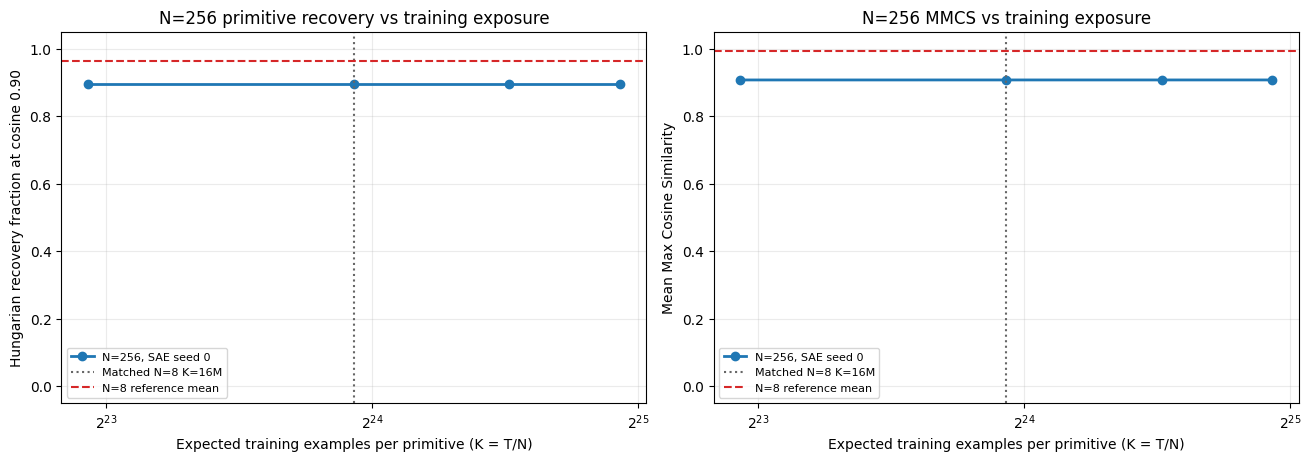

In [11]:
n8_reference = load_n8_reference()
print(
    'N=8 reference:',
    f'H90={n8_reference["hungarian_90_mean"]:.4f},',
    f'MMCS={n8_reference["mmcs_mean"]:.4f}',
)


def plot_learning_curve(
    ax,
    frame: pd.DataFrame,
    *,
    metric: str,
    title: str,
    ylabel: str,
    reference_mean: float,
) -> None:
    ordered = frame.sort_values('k_expected_samples_per_primitive')
    ax.plot(
        ordered['k_expected_samples_per_primitive'],
        ordered[metric],
        marker='o',
        linewidth=2,
        label='N=256, SAE seed 0',
    )
    ax.axvline(
        16_000_000, color='0.4', linestyle=':', label='Matched N=8 K=16M'
    )
    ax.axhline(
        reference_mean, color='C3', linestyle='--', label='N=8 reference mean'
    )
    ax.set_xscale('log', base=2)
    ax.set(
        title=title,
        xlabel='Expected training examples per primitive (K = T/N)',
        ylabel=ylabel,
        ylim=(-0.05, 1.05),
    )
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)


if results is not None:
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
    plot_learning_curve(
        axes[0],
        results,
        metric='hungarian_90',
        title='N=256 primitive recovery vs training exposure',
        ylabel='Hungarian recovery fraction at cosine 0.90',
        reference_mean=float(n8_reference['hungarian_90_mean']),
    )
    plot_learning_curve(
        axes[1],
        results,
        metric='mmcs',
        title='N=256 MMCS vs training exposure',
        ylabel='Mean Max Cosine Similarity',
        reference_mean=float(n8_reference['mmcs_mean']),
    )
    plot_path = RESULTS_ROOT / f'fixed_exposure_{run_label}_recovery_curves.png'
    figure.savefig(plot_path, dpi=200, bbox_inches='tight')
    print('Saved', plot_path)
    plt.show()


## Interpretation checklist

1. **Lower exposure point:** `K=8M` corresponds to `T=2.048B`, half the successful
   `N=8` exposure per primitive.
2. **Primary matched-exposure test:** compare `N=256, K=16M` (`T=4.096B`) against the five-seed
   `N=8, K=16M` reference (`H90 ≈ 0.963`, `MMCS ≈ 0.992`).
3. **Full recovery:** `hungarian_90 == 1.0` means all 512 primitives have distinct
   decoder matches at cosine at least 0.90.
4. **Beyond matched exposure:** determine whether `K=24M` (`T=6.144B`) and
   `K=32M` (`T=8.192B`) continue improving, plateau, or degrade.
5. **Fit versus representation:** interpret recovery alongside FVU, `L0`, and dead
   latents. Low FVU with low recovery means the SAE fits using a non-ground-truth
   dictionary; high FVU means optimization/training itself remains inadequate.

A restoration of recovery with increasing `K` supports a **training-exposure**
explanation. It should not be described as uniquely proving a data-diversity effect,
because this online generator supplies fresh samples and every increase in `K` also
adds optimizer updates.


# Experiment 4B — Independent SAE initializations at `K=32M`

The learning-curve experiment above used one continuous SAE seed-0 trajectory. Its flat recovery from `K=8M` through `K=32M` suggests an exposure plateau, but one trajectory cannot measure sensitivity to the non-convex SAE initialization.

This follow-up evaluates **three total SAE initialization seeds `(0, 1, 2)`** at the largest exposure, `K=32M` (`T=8.192B`). The completed seed-0 checkpoint is reused; seeds 1 and 2 are new from-scratch training trajectories. Dictionary seed, data seed, generated sample order, optimizer, and all SAE hyperparameters remain fixed, isolating SAE initialization as the experimental variable.

Intermediate `K=8M`, `16M`, and `24M` checkpoints are saved only to make the two new 8.192B-sample runs resumable. Only the `K=32M` checkpoints enter this comparison.

In [12]:
K32_TARGET_K = 32_000_000
K32_SAE_SEEDS = (0, 1, 2)
K32_RESUME_MILESTONES = tuple(
    K32_TARGET_K * fraction // 4 for fraction in (1, 2, 3, 4)
)
RUN_K32_THREE_SEED_EXPERIMENT = False

K32_RESULTS_PATH = (
    RESULTS_ROOT / 'fixed_exposure_K32m_three_sae_seeds.csv'
)
K32_SUMMARY_PATH = (
    RESULTS_ROOT / 'fixed_exposure_K32m_three_sae_seeds_summary.csv'
)

assert K32_TARGET_K == K_VALUES[-1]
assert K32_RESUME_MILESTONES[-1] == K32_TARGET_K
for k in K32_RESUME_MILESTONES:
    assert (k * N_PER_SET) % TRAIN_BATCH_SIZE == 0

completed_k32_seeds = [
    seed for seed in K32_SAE_SEEDS
    if checkpoint_is_resumable(milestone_path(seed, K32_TARGET_K))
]
pending_k32_seeds = [
    seed for seed in K32_SAE_SEEDS if seed not in completed_k32_seeds
]
print('K=32M SAE seeds:', K32_SAE_SEEDS)
print('Already complete:', completed_k32_seeds)
print('Pending from-scratch/resume trajectories:', pending_k32_seeds)
print('Samples per complete trajectory:', f'{K32_TARGET_K * N_PER_SET:,}')
print('Resumability milestones:', K32_RESUME_MILESTONES)

K=32M SAE seeds: (0, 1, 2)
Already complete: []
Pending from-scratch/resume trajectories: [0, 1, 2]
Samples per complete trajectory: 8,192,000,000
Resumability milestones: (8000000, 16000000, 24000000, 32000000)


## Train or resume the three `K=32M` trajectories

With the existing artifacts, seed 0 should print that all milestones are complete. Seeds 1 and 2 each produce one progress bar ending at 8.192B samples. Re-running the cell resumes from the latest complete intermediate milestone rather than restarting a finished segment.

In [13]:
k32_seed_results = None
if RUN_K32_THREE_SEED_EXPERIMENT:
    for sae_seed in K32_SAE_SEEDS:
        ensure_seed_trajectory(sae_seed, K32_RESUME_MILESTONES)
    k32_seed_results = evaluate_saved_milestones(
        K32_SAE_SEEDS, (K32_TARGET_K,), K32_RESULTS_PATH
    )
elif K32_RESULTS_PATH.exists():
    k32_seed_results = pd.read_csv(K32_RESULTS_PATH)
else:
    print(
        'Set RUN_K32_THREE_SEED_EXPERIMENT=True to launch the '
        'K=32M trajectories.'
    )

if k32_seed_results is not None:
    display(k32_seed_results.style.format({
        'k_expected_samples_per_primitive': '{:,.0f}',
        'training_samples': '{:,.0f}',
        'optimizer_steps': '{:,.0f}',
        'expected_samples_per_pair': '{:,.1f}',
        'hungarian_90': '{:.4f}',
        'mmcs': '{:.6f}',
        'hungarian_assigned_cosine_mean': '{:.6f}',
        'hungarian_assigned_cosine_min': '{:.6f}',
        'eval_fvu': '{:.6f}',
        'eval_mean_l0': '{:.4f}',
        'eval_mean_l1': '{:.4f}',
        'eval_dead_latent_fraction': '{:.4f}',
    }))

Set RUN_K32_THREE_SEED_EXPERIMENT=True to launch the K=32M trajectories.


## Three-seed aggregation and comparison

The table reports mean, sample standard deviation, minimum, and maximum across the three independent SAE initializations. The plot shows every seed individually, the three-seed mean, and the five-seed `N=8`, `K=16M` reference.

In [14]:
K32_REPORTED_METRICS = [
    'hungarian_90', 'mmcs', 'hungarian_assigned_cosine_mean',
    'hungarian_assigned_cosine_min', 'eval_fvu', 'eval_mean_l0',
    'eval_mean_l1', 'eval_dead_latent_fraction',
]

if k32_seed_results is not None:
    k32_seed_summary = (
        k32_seed_results[K32_REPORTED_METRICS]
        .agg(['mean', 'std', 'min', 'max'])
        .T.reset_index(names='metric')
    )
    k32_seed_summary.to_csv(K32_SUMMARY_PATH, index=False)
    display(k32_seed_summary.style.format({
        'mean': '{:.6f}', 'std': '{:.6f}',
        'min': '{:.6f}', 'max': '{:.6f}',
    }))

    if 'n8_reference' not in globals():
        n8_reference = load_n8_reference()

    figure, axes = plt.subplots(
        1, 2, figsize=(12, 4.5), constrained_layout=True
    )
    plot_specs = (
        ('hungarian_90', 'hungarian_90_mean',
         'Hungarian recovery fraction at cosine 0.90'),
        ('mmcs', 'mmcs_mean', 'Mean Max Cosine Similarity'),
    )
    for ax, (metric, reference_metric, ylabel) in zip(axes, plot_specs):
        values = k32_seed_results.sort_values('sae_seed')
        ax.scatter(
            values['sae_seed'], values[metric],
            s=70, color='C0', label='N=256 individual seeds', zorder=3,
        )
        ax.axhline(
            values[metric].mean(), color='C0', linestyle='-',
            label='N=256 three-seed mean',
        )
        ax.axhline(
            float(n8_reference[reference_metric]),
            color='C3', linestyle='--', label='N=8 reference mean',
        )
        ax.set(
            title=f'N=256, K=32M: {metric} across SAE seeds',
            xlabel='SAE initialization seed', ylabel=ylabel,
            xticks=list(K32_SAE_SEEDS), ylim=(-0.05, 1.05),
        )
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)

    k32_plot_path = (
        RESULTS_ROOT / 'fixed_exposure_K32m_three_sae_seeds.png'
    )
    figure.savefig(k32_plot_path, dpi=200, bbox_inches='tight')
    print('Saved', K32_RESULTS_PATH)
    print('Saved', K32_SUMMARY_PATH)
    print('Saved', k32_plot_path)
    plt.show()

## Interpretation

- If all three seeds remain near the original seed-0 plateau, the evidence favors an objective or identifiability limitation rather than insufficient exposure or an unlucky initialization.
- If one or more seeds recover substantially better, the plateau is basin-dependent and should be characterized with more initialization seeds.
- These runs intentionally share the same generated sample sequence. They estimate initialization sensitivity, not data-stream sensitivity. Testing data-stream sensitivity would keep the SAE seed fixed and vary `DATA_SEED`.

# Experiment 4C — Successive-halving hyperparameter search

Experiment 4B showed that additional data and SAE initialization seeds do not move the fixed Standard SAE far from its recovery plateau. Experiment 4C tests whether that plateau is specific to the optimization and sparsity settings.

## Quantities varied

The full Cartesian grid contains **90 configurations**:

| Quantity | Values | Count |
|---|---:|---:|
| L1 coefficient | `0.03, 0.1, 0.2, 0.3, 0.5` | 5 |
| Learning rate | `1e-4, 3e-4, 1e-3` | 3 |
| LR schedule | constant; 2% warmup + cosine; 5% warmup + cosine | 3 |
| Adam beta1 | `0.0, 0.9` | 2 |

Thus `5 × 3 × 3 × 2 = 90`. For cosine schedules, the learning rate warms linearly to the configured peak and then decays to 1% of that peak. The constant schedule has no warmup.

## Quantities held constant

`d_sae=512`, batch size `16384`, Adam beta2 `0.999`, weight decay `0.01`, StandardTrainingSAE, decoder initialization norm `1.0`, no L1 warmup, no input normalization, `apply_b_dec_to_input=False`, and the same dictionary/data construction as Experiments 4 and 4B. SAELens constructs `torch.optim.Adam` without exposing weight decay in `SAETrainerConfig`, so this notebook sets `weight_decay=0.01` on every Adam parameter group. This is Adam's coupled L2 weight decay, not AdamW.

Experiment 4C files are stored beneath `artifacts/04_fixed_primitive_exposure/experiment_4c_hyperparameter_sweep_batch16384`. Locally this is inside the existing checkout; with `USE_GOOGLE_DRIVE=True` on Colab, it is persisted inside the Drive-backed clone.

In [15]:
from itertools import product

E4C_L1_COEFFICIENTS = (0.03, 0.1, 0.2, 0.3, 0.5)
E4C_LEARNING_RATES = (1e-4, 3e-4, 1e-3)
E4C_SCHEDULES = (
    ('constant', 0.00),
    ('cosineannealing', 0.02),
    ('cosineannealing', 0.05),
)
E4C_ADAM_BETA1_VALUES = (0.0, 0.9)

E4C_D_SAE = 512
E4C_BATCH_SIZE = 16_384
E4C_ADAM_BETA2 = 0.999
E4C_WEIGHT_DECAY = 0.01
E4C_LR_END_FRACTION = 0.01
E4C_CHECKPOINT_FRACTIONS = (0.25, 0.50, 0.75, 1.00)

E4C_ROOT = ARTIFACT_ROOT / 'experiment_4c_hyperparameter_sweep_batch16384'
E4C_CHECKPOINT_ROOT = E4C_ROOT / 'checkpoints'
E4C_RESULTS_ROOT = E4C_ROOT / 'results'
for path in (E4C_CHECKPOINT_ROOT, E4C_RESULTS_ROOT):
    path.mkdir(parents=True, exist_ok=True)

e4c_configs = []
for index, (l1, lr, schedule_and_warmup, beta1) in enumerate(product(
    E4C_L1_COEFFICIENTS, E4C_LEARNING_RATES, E4C_SCHEDULES,
    E4C_ADAM_BETA1_VALUES,
)):
    scheduler, warmup_fraction = schedule_and_warmup
    e4c_configs.append({
        'config_id': f'c{index:03d}',
        'l1_coefficient': float(l1),
        'learning_rate': float(lr),
        'scheduler': scheduler,
        'warmup_fraction': float(warmup_fraction),
        'adam_beta1': float(beta1),
    })

assert len(e4c_configs) == 90
assert E4C_D_SAE == D_SAE == 512
assert E4C_BATCH_SIZE == TRAIN_BATCH_SIZE == 16_384
e4c_grid = pd.DataFrame(e4c_configs)
e4c_grid.to_csv(E4C_RESULTS_ROOT / 'configuration_grid.csv', index=False)
display(e4c_grid)
print('Varied configurations:', len(e4c_grid))
print('Fixed: d_sae=512, batch=16384, beta2=0.999, weight_decay=0.01')


,config_id,l1_coefficient,learning_rate,scheduler,warmup_fraction,adam_beta1
0,c000,0.03,0.0001,constant,0.00,0.0
1,c001,0.03,0.0001,constant,0.00,0.9
2,c002,0.03,0.0001,cosineannealing,0.02,0.0
3,c003,0.03,0.0001,cosineannealing,0.02,0.9
4,c004,0.03,0.0001,cosineannealing,0.05,0.0
...,...,...,...,...,...,...
85,c085,0.50,0.0010,constant,0.00,0.9
86,c086,0.50,0.0010,cosineannealing,0.02,0.0
87,c087,0.50,0.0010,cosineannealing,0.02,0.9
88,c088,0.50,0.0010,cosineannealing,0.05,0.0


Varied configurations: 90
Fixed: d_sae=512, batch=16384, beta2=0.999, weight_decay=0.01


## Promotion design and compute budget

Training all 90 configurations directly at `K=32M` would require 737.28 billion activations. Instead, the sweep uses successive halving. The first two stages cheaply eliminate poor configurations, `K=2M` selects with two initialization seeds, `K=8M` selects the winner with three seeds, and `K=32M` confirms that winner with three seeds.

Every configuration is trained **from scratch at each promoted stage**. This is deliberate: a cosine schedule that ended at a small budget cannot be fairly extended to a larger budget. Within a stage, checkpoints are placed at the nearest whole optimizer step to each quarter; they save model, optimizer, scheduler, activation-scaler, and data-generator RNG state so interrupted GPU runs resume safely. The same data seed is used across configurations, while the listed SAE seeds vary initialization.

Promotion ranking is primitive-recovery-first: worst-seed Hungarian recovery at cosine 0.90, mean Hungarian recovery, worst/mean Hungarian assigned cosine, then MMCS; lower FVU is only a final tie-breaker.

In [16]:
E4C_STAGES = (
    {'name': 'screen_k64k', 'k': 64_000, 'seeds': (0,), 'keep': 18},
    {'name': 'select_k512k', 'k': 512_000, 'seeds': (0,), 'keep': 6},
    {'name': 'semifinal_k2m', 'k': 2_000_000, 'seeds': (0, 1), 'keep': 2},
    {'name': 'final_k8m', 'k': 8_000_000, 'seeds': (0, 1, 2), 'keep': 1},
    {'name': 'confirm_k32m', 'k': 32_000_000, 'seeds': (0, 1, 2), 'keep': None},
)

RUN_EXPERIMENT_4C = True
MAX_E4C_STAGE = 'confirm_k32m'

assert RUN_EXPERIMENT is False
assert RUN_K32_THREE_SEED_EXPERIMENT is False
assert RUN_EXPERIMENT_4C is True

stage_names = [stage['name'] for stage in E4C_STAGES]
if MAX_E4C_STAGE not in stage_names:
    raise ValueError(f'Unknown MAX_E4C_STAGE: {MAX_E4C_STAGE}')
for stage in E4C_STAGES:
    total_samples = stage['k'] * N_PER_SET
    assert total_samples % E4C_BATCH_SIZE == 0

remaining = len(e4c_configs)
budget_rows = []
for stage in E4C_STAGES:
    runs = remaining * len(stage['seeds'])
    samples_per_run = stage['k'] * N_PER_SET
    budget_rows.append({
        'stage': stage['name'], 'candidate_configs': remaining,
        'sae_seeds': len(stage['seeds']), 'runs': runs,
        'K_per_primitive': stage['k'],
        'samples_per_run': samples_per_run,
        'optimizer_steps_per_run': samples_per_run // E4C_BATCH_SIZE,
        'maximum_stage_samples': runs * samples_per_run,
        'promote': stage['keep'],
    })
    if stage['keep'] is not None:
        remaining = stage['keep']
e4c_budget = pd.DataFrame(budget_rows)
e4c_budget.to_csv(E4C_RESULTS_ROOT / 'compute_budget.csv', index=False)
e4c_manifest = {
    'experiment': '4C',
    'architecture': 'StandardTrainingSAE',
    'varied_hyperparameters': {
        'l1_coefficient': list(E4C_L1_COEFFICIENTS),
        'learning_rate': list(E4C_LEARNING_RATES),
        'schedule_and_warmup_fraction': [list(value) for value in E4C_SCHEDULES],
        'adam_beta1': list(E4C_ADAM_BETA1_VALUES),
    },
    'fixed_hyperparameters': {
        'd_sae': E4C_D_SAE,
        'train_batch_size': E4C_BATCH_SIZE,
        'adam_beta2': E4C_ADAM_BETA2,
        'weight_decay': E4C_WEIGHT_DECAY,
        'cosine_lr_end_fraction': E4C_LR_END_FRACTION,
        'decoder_init_norm': 1.0,
        'l1_warm_up_steps': 0,
        'dictionary_seed': DICTIONARY_SEED,
        'data_seed': DATA_SEED,
        'evaluation_seed': EVAL_SEED,
        'evaluation_samples': EVAL_SAMPLES,
    },
    'stages': list(E4C_STAGES),
    'ranking_order': [
        'hungarian_90_worst', 'hungarian_90_mean',
        'hungarian_cosine_worst', 'hungarian_cosine_mean',
        'mmcs_mean', 'eval_fvu_mean_ascending',
    ],
}
(E4C_RESULTS_ROOT / 'experiment_manifest.json').write_text(
    json.dumps(e4c_manifest, indent=2) + '\n'
)
display(e4c_budget.style.format({
    'K_per_primitive': '{:,.0f}', 'samples_per_run': '{:,.0f}',
    'optimizer_steps_per_run': '{:,.0f}',
    'maximum_stage_samples': '{:,.0f}',
}))
print(
    'Maximum end-to-end activation budget:',
    f"{e4c_budget['maximum_stage_samples'].sum():,.0f}",
)
print('Run flag:', RUN_EXPERIMENT_4C)
print('Maximum stage:', MAX_E4C_STAGE)


,stage,candidate_configs,sae_seeds,runs,K_per_primitive,samples_per_run,optimizer_steps_per_run,maximum_stage_samples,promote
0,screen_k64k,90,1,90,"64,000","16,384,000","1,000","1,474,560,000",18.000000
1,select_k512k,18,1,18,"512,000","131,072,000","8,000","2,359,296,000",6.000000
2,semifinal_k2m,6,2,12,"2,000,000","512,000,000","31,250","6,144,000,000",2.000000
3,final_k8m,2,3,6,"8,000,000","2,048,000,000","125,000","12,288,000,000",1.000000
4,confirm_k32m,1,3,3,"32,000,000","8,192,000,000","500,000","24,576,000,000",nan


Maximum end-to-end activation budget: 46,841,856,000
Run flag: True
Maximum stage: confirm_k32m


## Resumable local training helpers

Each run directory includes an immutable `run_spec.json`. If code settings and an existing checkpoint disagree, the notebook raises an error instead of silently loading an incompatible model. Checkpoints near each quarter of the optimizer-step budget make long GPU runs resumable.

In [17]:
E4C_RESULT_COLUMNS = [
    'stage', 'config_id', 'sae_seed', 'n_per_set', 'dictionary_seed',
    'data_seed', 'd_sae', 'train_batch_size', 'l1_coefficient',
    'learning_rate', 'scheduler', 'warmup_fraction', 'warmup_steps',
    'adam_beta1', 'adam_beta2', 'weight_decay',
    'k_expected_samples_per_primitive', 'training_samples',
    'optimizer_steps', 'hungarian_90', 'mmcs',
    'hungarian_assigned_cosine_mean',
    'hungarian_assigned_cosine_min', 'eval_fvu', 'eval_mean_l0',
    'eval_mean_l1', 'eval_dead_latent_fraction',
]


def e4c_run_root(stage_name: str, config_id: str, sae_seed: int) -> Path:
    return (
        E4C_CHECKPOINT_ROOT / stage_name / config_id / f'seed_{sae_seed}'
    )


def e4c_run_spec(
    stage: dict, config: dict, sae_seed: int
) -> dict:
    total_samples = int(stage['k'] * N_PER_SET)
    total_steps = total_samples // E4C_BATCH_SIZE
    warmup_steps = int(round(total_steps * config['warmup_fraction']))
    return {
        'stage': stage['name'],
        'config_id': config['config_id'],
        'sae_seed': int(sae_seed),
        'n_per_set': N_PER_SET,
        'activation_dim': ACTIVATION_DIM,
        'dictionary_seed': DICTIONARY_SEED,
        'data_seed': DATA_SEED,
        'd_sae': E4C_D_SAE,
        'train_batch_size': E4C_BATCH_SIZE,
        'l1_coefficient': config['l1_coefficient'],
        'learning_rate': config['learning_rate'],
        'scheduler': config['scheduler'],
        'warmup_fraction': config['warmup_fraction'],
        'warmup_steps': warmup_steps,
        'adam_beta1': config['adam_beta1'],
        'adam_beta2': E4C_ADAM_BETA2,
        'weight_decay': E4C_WEIGHT_DECAY,
        'k_expected_samples_per_primitive': int(stage['k']),
        'training_samples': total_samples,
        'optimizer_steps': total_steps,
    }


def e4c_prepare_run_root(spec: dict) -> Path:
    root = e4c_run_root(spec['stage'], spec['config_id'], spec['sae_seed'])
    root.mkdir(parents=True, exist_ok=True)
    spec_path = root / 'run_spec.json'
    if spec_path.exists():
        saved = json.loads(spec_path.read_text())
        if saved != spec:
            raise ValueError(
                f'Existing Experiment 4C run has incompatible settings: {root}'
            )
    else:
        spec_path.write_text(json.dumps(spec, indent=2) + '\n')
    return root


def make_e4c_sae(config: dict, sae_seed: int) -> StandardTrainingSAE:
    torch.manual_seed(sae_seed)
    cfg = StandardTrainingSAEConfig(
        d_in=ACTIVATION_DIM,
        d_sae=E4C_D_SAE,
        device=str(DEVICE),
        dtype='float32',
        apply_b_dec_to_input=False,
        normalize_activations='none',
        l1_coefficient=config['l1_coefficient'],
        lp_norm=1.0,
        l1_warm_up_steps=0,
        decoder_init_norm=1.0,
    )
    return StandardTrainingSAE(cfg).to(DEVICE)


def e4c_apply_weight_decay(trainer: SAETrainer) -> None:
    for parameter_group in trainer.optimizer.param_groups:
        parameter_group['weight_decay'] = E4C_WEIGHT_DECAY


def make_e4c_trainer(
    sae: StandardTrainingSAE, generator: SparseFactorialGenerator,
    *, spec: dict,
) -> SAETrainer:
    learning_rate = spec['learning_rate']
    is_cosine = spec['scheduler'] == 'cosineannealing'
    cfg = SAETrainerConfig(
        total_training_samples=spec['training_samples'],
        train_batch_size_samples=E4C_BATCH_SIZE,
        lr=learning_rate,
        lr_end=(
            learning_rate * E4C_LR_END_FRACTION
            if is_cosine else learning_rate
        ),
        lr_scheduler_name=spec['scheduler'],
        lr_warm_up_steps=spec['warmup_steps'],
        lr_decay_steps=0,
        adam_beta1=spec['adam_beta1'],
        adam_beta2=E4C_ADAM_BETA2,
        device=str(DEVICE),
        n_checkpoints=0,
        checkpoint_path=None,
        save_final_checkpoint=False,
        logger=LoggingConfig(
            log_to_wandb=False,
            eval_every_n_wandb_logs=2**31 - 1,
        ),
        n_batches_for_norm_estimate=1,
    )
    trainer = SAETrainer(
        cfg=cfg, sae=sae,
        data_provider=SparseFactorialActivationIterator(
            generator, E4C_BATCH_SIZE
        ),
    )
    e4c_apply_weight_decay(trainer)
    return trainer


def e4c_checkpoint_is_complete(path: Path) -> bool:
    required = (
        'cfg.json', 'sae_weights.safetensors', 'trainer_state.pt',
        'activation_scaler.json', 'generator_rng_state.pt',
        'checkpoint_spec.json',
    )
    return path.is_dir() and all((path / name).is_file() for name in required)


def e4c_checkpoint_samples(path: Path) -> int:
    metadata = json.loads((path / 'checkpoint_spec.json').read_text())
    return int(metadata['completed_training_samples'])


def e4c_latest_checkpoint(run_root: Path, target_samples: int) -> Path | None:
    candidates = [
        path for path in run_root.glob('checkpoint_T*')
        if e4c_checkpoint_is_complete(path)
        and e4c_checkpoint_samples(path) <= target_samples
    ]
    return max(candidates, key=e4c_checkpoint_samples, default=None)


def refresh_e4c_checkpoint_index() -> pd.DataFrame:
    rows = []
    for spec_path in E4C_CHECKPOINT_ROOT.glob(
        '*/*/seed_*/checkpoint_T*/checkpoint_spec.json'
    ):
        row = json.loads(spec_path.read_text())
        row['checkpoint_path'] = str(
            spec_path.parent.relative_to(E4C_ROOT)
        )
        rows.append(row)
    checkpoint_index = pd.DataFrame(rows)
    if not checkpoint_index.empty:
        checkpoint_index = checkpoint_index.sort_values(
            [
                'stage', 'config_id', 'sae_seed',
                'completed_training_samples',
            ]
        ).reset_index(drop=True)
        checkpoint_index.to_csv(
            E4C_RESULTS_ROOT / 'checkpoint_index.csv', index=False
        )
    return checkpoint_index


def save_e4c_checkpoint(
    trainer: SAETrainer, generator: SparseFactorialGenerator,
    *, run_root: Path, spec: dict,
) -> Path:
    completed = int(trainer.n_training_samples)
    checkpoint_name = f'checkpoint_T{completed:015d}'
    checkpoint = run_root / checkpoint_name
    trainer.save_checkpoint(checkpoint_name=checkpoint_name, base_path=run_root)
    torch.save(generator.rng.get_state(), checkpoint / 'generator_rng_state.pt')
    checkpoint_spec = {
        **spec,
        'completed_training_samples': completed,
        'completed_optimizer_steps': int(trainer.n_training_steps),
    }
    (checkpoint / 'checkpoint_spec.json').write_text(
        json.dumps(checkpoint_spec, indent=2) + '\n'
    )
    refresh_e4c_checkpoint_index()
    return checkpoint


In [18]:
def train_or_resume_e4c_run(
    stage: dict, config: dict, sae_seed: int
) -> Path:
    spec = e4c_run_spec(stage, config, sae_seed)
    run_root = e4c_prepare_run_root(spec)
    target_samples = spec['training_samples']
    latest = e4c_latest_checkpoint(run_root, target_samples)
    if latest is not None and e4c_checkpoint_samples(latest) == target_samples:
        print('Loaded complete run:', run_root)
        return latest

    generator = build_generator(DATA_SEED)
    if latest is None:
        sae = make_e4c_sae(config, sae_seed)
        trainer = make_e4c_trainer(sae, generator, spec=spec)
    else:
        sae = StandardTrainingSAE.load_from_disk(
            latest, device=str(DEVICE), dtype='float32'
        ).to(DEVICE)
        trainer = make_e4c_trainer(sae, generator, spec=spec)
        trainer.load_trainer_state(latest)
        e4c_apply_weight_decay(trainer)
        generator_state = torch.load(
            latest / 'generator_rng_state.pt', map_location='cpu'
        )
        generator.rng.set_state(generator_state)

    target_steps = spec['optimizer_steps']
    checkpoint_step_targets = sorted({
        max(1, min(target_steps, int(round(target_steps * fraction))))
        for fraction in E4C_CHECKPOINT_FRACTIONS
    })
    if checkpoint_step_targets[-1] != target_steps:
        checkpoint_step_targets.append(target_steps)
    checkpoint_targets = [
        steps * E4C_BATCH_SIZE for steps in checkpoint_step_targets
    ]
    assert checkpoint_targets[-1] == target_samples

    description = (
        f"{stage['name']} {config['config_id']} seed={sae_seed}"
    )
    progress = tqdm(
        total=target_samples, initial=trainer.n_training_samples,
        desc=description,
    )
    for checkpoint_target in checkpoint_targets:
        if trainer.n_training_samples >= checkpoint_target:
            continue
        while trainer.n_training_samples < checkpoint_target:
            trainer.maybe_reset_sparsity()
            trainer.step(next(trainer.data_provider))
            trainer.n_training_steps += 1
            progress.update(E4C_BATCH_SIZE)
        if trainer.n_training_samples != checkpoint_target:
            raise RuntimeError('Experiment 4C target was overshot.')
        checkpoint = save_e4c_checkpoint(
            trainer, generator, run_root=run_root, spec=spec
        )
        print(f'\nSaved {checkpoint}')
    progress.close()

    final_checkpoint = e4c_latest_checkpoint(run_root, target_samples)
    if (
        final_checkpoint is None
        or e4c_checkpoint_samples(final_checkpoint) != target_samples
    ):
        raise RuntimeError(f'Final checkpoint missing for {run_root}')
    del trainer, sae
    if DEVICE.type == 'mps':
        torch.mps.empty_cache()
    elif DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    return final_checkpoint


def evaluate_e4c_checkpoint(
    checkpoint: Path, stage: dict, config: dict, sae_seed: int
) -> dict:
    spec = e4c_run_spec(stage, config, sae_seed)
    checkpoint_spec = json.loads(
        (checkpoint / 'checkpoint_spec.json').read_text()
    )
    if checkpoint_spec['completed_training_samples'] != spec['training_samples']:
        raise ValueError(f'Checkpoint has the wrong training budget: {checkpoint}')
    sae = StandardTrainingSAE.load_from_disk(
        checkpoint, device=str(DEVICE), dtype='float32'
    ).to(DEVICE)
    row = {
        **spec,
        **primitive_recovery_metrics(sae, TRUE_DICTIONARY),
        **training_quality_metrics(sae),
    }
    del sae
    if DEVICE.type == 'mps':
        torch.mps.empty_cache()
    elif DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    return row


def e4c_results_path(stage_name: str) -> Path:
    return E4C_RESULTS_ROOT / f'{stage_name}_results.csv'


def save_e4c_all_raw_results() -> pd.DataFrame:
    frames = []
    for stage_index, stage in enumerate(E4C_STAGES):
        path = e4c_results_path(stage['name'])
        if not path.is_file():
            continue
        frame = pd.read_csv(path)
        frame.insert(0, '_stage_index', stage_index)
        frames.append(frame)
    if not frames:
        return pd.DataFrame(columns=E4C_RESULT_COLUMNS)
    combined = (
        pd.concat(frames, ignore_index=True)
        .sort_values(['_stage_index', 'config_id', 'sae_seed'])
        .drop(columns='_stage_index')
        .reset_index(drop=True)
    )
    combined.to_csv(E4C_RESULTS_ROOT / 'all_stage_results.csv', index=False)
    return combined


def run_e4c_stage(stage: dict, configs: Sequence[dict]) -> pd.DataFrame:
    output_path = e4c_results_path(stage['name'])
    if output_path.is_file():
        results = pd.read_csv(output_path)
    else:
        results = pd.DataFrame(columns=E4C_RESULT_COLUMNS)

    completed_keys = set()
    if not results.empty:
        completed_keys = set(zip(results['config_id'], results['sae_seed']))
    for config in configs:
        for sae_seed in stage['seeds']:
            key = (config['config_id'], sae_seed)
            if key in completed_keys:
                print('Loaded result:', stage['name'], *key)
                continue
            checkpoint = train_or_resume_e4c_run(stage, config, sae_seed)
            row = evaluate_e4c_checkpoint(
                checkpoint, stage, config, sae_seed
            )
            results = pd.concat(
                [results, pd.DataFrame([row])], ignore_index=True
            )
            results = (
                results[E4C_RESULT_COLUMNS]
                .drop_duplicates(['config_id', 'sae_seed'], keep='last')
                .sort_values(['config_id', 'sae_seed'])
                .reset_index(drop=True)
            )
            results.to_csv(output_path, index=False)
            save_e4c_all_raw_results()
            completed_keys.add(key)
            print(
                f"Evaluated {stage['name']} {config['config_id']} "
                f"seed={sae_seed}: H90={row['hungarian_90']:.4f}, "
                f"MMCS={row['mmcs']:.4f}"
            )
    return results


In [19]:
def summarize_e4c_stage(results: pd.DataFrame) -> pd.DataFrame:
    summary = (
        results.groupby(
            [
                'stage', 'config_id', 'l1_coefficient', 'learning_rate',
                'scheduler', 'warmup_fraction', 'adam_beta1',
            ],
            as_index=False,
        )
        .agg(
            n_seeds=('sae_seed', 'nunique'),
            hungarian_90_worst=('hungarian_90', 'min'),
            hungarian_90_mean=('hungarian_90', 'mean'),
            hungarian_cosine_worst=(
                'hungarian_assigned_cosine_mean', 'min'
            ),
            hungarian_cosine_mean=(
                'hungarian_assigned_cosine_mean', 'mean'
            ),
            mmcs_mean=('mmcs', 'mean'),
            eval_fvu_mean=('eval_fvu', 'mean'),
            eval_l0_mean=('eval_mean_l0', 'mean'),
            dead_latent_fraction_mean=(
                'eval_dead_latent_fraction', 'mean'
            ),
        )
    )
    summary = summary.sort_values(
        [
            'hungarian_90_worst', 'hungarian_90_mean',
            'hungarian_cosine_worst', 'hungarian_cosine_mean',
            'mmcs_mean', 'eval_fvu_mean',
        ],
        ascending=[False, False, False, False, False, True],
    ).reset_index(drop=True)
    summary.insert(0, 'rank', range(1, len(summary) + 1))
    return summary


def save_e4c_all_summaries() -> tuple[pd.DataFrame, pd.DataFrame]:
    frames = []
    for stage_index, stage in enumerate(E4C_STAGES):
        path = E4C_RESULTS_ROOT / f"{stage['name']}_summary.csv"
        if not path.is_file():
            continue
        frame = pd.read_csv(path)
        frame.insert(0, '_stage_index', stage_index)
        frames.append(frame)
    if not frames:
        return pd.DataFrame(), pd.DataFrame()
    combined = (
        pd.concat(frames, ignore_index=True)
        .sort_values(['_stage_index', 'rank'])
        .reset_index(drop=True)
    )
    best_by_stage = (
        combined.loc[combined['rank'] == 1]
        .sort_values('_stage_index')
        .reset_index(drop=True)
    )
    combined.drop(columns='_stage_index').to_csv(
        E4C_RESULTS_ROOT / 'all_stage_summaries.csv', index=False
    )
    best_by_stage.drop(columns='_stage_index').to_csv(
        E4C_RESULTS_ROOT / 'best_configuration_by_stage.csv', index=False
    )
    best_by_stage.tail(1).drop(columns='_stage_index').to_csv(
        E4C_RESULTS_ROOT / 'best_available_configuration.csv', index=False
    )
    return (
        combined.drop(columns='_stage_index'),
        best_by_stage.drop(columns='_stage_index'),
    )


def e4c_expected_keys(
    stage: dict, configs: Sequence[dict]
) -> set[tuple[str, int]]:
    return {
        (config['config_id'], seed)
        for config in configs for seed in stage['seeds']
    }


def e4c_stage_is_complete(
    stage: dict, configs: Sequence[dict], results: pd.DataFrame
) -> bool:
    actual = set(zip(results['config_id'], results['sae_seed']))
    return e4c_expected_keys(stage, configs) <= actual


def select_e4c_promotions(
    summary: pd.DataFrame, configs: Sequence[dict], keep: int
) -> list[dict]:
    promoted_ids = set(summary.head(keep)['config_id'])
    return [
        config for config in configs if config['config_id'] in promoted_ids
    ]


def run_or_load_e4c_successive_halving() -> tuple[dict, dict]:
    candidates = list(e4c_configs)
    stage_summaries = {}
    promotion_rows = []
    stop_index = stage_names.index(MAX_E4C_STAGE)

    for stage_index, stage in enumerate(E4C_STAGES):
        if stage_index > stop_index:
            break
        results_path = e4c_results_path(stage['name'])
        print(
            f"\n{stage['name']}: {len(candidates)} configurations × "
            f"{len(stage['seeds'])} seeds"
        )
        if RUN_EXPERIMENT_4C:
            results = run_e4c_stage(stage, candidates)
        elif results_path.is_file():
            results = pd.read_csv(results_path)
        else:
            print(
                f'Missing {results_path}. Set RUN_EXPERIMENT_4C=True '
                'to train this stage.'
            )
            break

        if not e4c_stage_is_complete(stage, candidates, results):
            expected = len(candidates) * len(stage['seeds'])
            print(
                f"Stage incomplete: found {len(results)} of {expected} results. "
                'No promotion was performed.'
            )
            break

        candidate_ids = {config['config_id'] for config in candidates}
        results = results[results['config_id'].isin(candidate_ids)].copy()
        summary = summarize_e4c_stage(results)
        summary_path = E4C_RESULTS_ROOT / f"{stage['name']}_summary.csv"
        summary.to_csv(summary_path, index=False)
        save_e4c_all_raw_results()
        save_e4c_all_summaries()
        stage_summaries[stage['name']] = summary
        display(summary.head(min(10, len(summary))))

        keep = stage['keep']
        if keep is None:
            break
        promoted = select_e4c_promotions(summary, candidates, keep)
        for config in promoted:
            promotion_rows.append({
                'from_stage': stage['name'],
                'config_id': config['config_id'],
                **{key: value for key, value in config.items()
                   if key != 'config_id'},
            })
        pd.DataFrame(promotion_rows).to_csv(
            E4C_RESULTS_ROOT / 'promotion_history.csv', index=False
        )
        candidates = promoted
        print('Promoted:', [config['config_id'] for config in candidates])

    return stage_summaries, {
        config['config_id']: config for config in candidates
    }


## Run or resume Experiment 4C

`RUN_EXPERIMENT_4C=True` is enabled for the Colab GPU run. Review the compute-budget table first. `MAX_E4C_STAGE` can be set to any stage name to stop after that stage; rerunning later resumes completed runs and continues promotion. Setting the flag to `False` only loads and summarizes stages whose CSV files already exist.

All displayed numerical results are persisted under `E4C_RESULTS_ROOT`. Per-stage raw and summary CSVs are accompanied by `all_stage_results.csv`, `all_stage_summaries.csv`, `best_configuration_by_stage.csv`, `best_available_configuration.csv`, `promotion_history.csv`, `configuration_grid.csv`, `compute_budget.csv`, `checkpoint_index.csv`, and `experiment_manifest.json`. The consolidated raw-results file is refreshed after every completed run, so a runtime interruption does not discard finished measurements.

In [20]:
e4c_stage_summaries, e4c_current_candidates = (
    run_or_load_e4c_successive_halving()
)

if e4c_stage_summaries:
    latest_stage_name = list(e4c_stage_summaries)[-1]
    print('Latest complete stage:', latest_stage_name)
    print('Current best configuration(s):')
    display(e4c_stage_summaries[latest_stage_name].head(5))



screen_k64k: 90 configurations × 1 seeds


screen_k64k c000 seed=0:   0%|          | 0/16384000 [00:00<?, ?it/s]


Saved /content/drive/MyDrive/SAE-CHECKPOINTS/composed-features/artifacts/04_fixed_primitive_exposure/experiment_4c_hyperparameter_sweep_batch16384/checkpoints/screen_k64k/c000/seed_0/checkpoint_T000000004096000

Saved /content/drive/MyDrive/SAE-CHECKPOINTS/composed-features/artifacts/04_fixed_primitive_exposure/experiment_4c_hyperparameter_sweep_batch16384/checkpoints/screen_k64k/c000/seed_0/checkpoint_T000000008192000

Saved /content/drive/MyDrive/SAE-CHECKPOINTS/composed-features/artifacts/04_fixed_primitive_exposure/experiment_4c_hyperparameter_sweep_batch16384/checkpoints/screen_k64k/c000/seed_0/checkpoint_T000000012288000

Saved /content/drive/MyDrive/SAE-CHECKPOINTS/composed-features/artifacts/04_fixed_primitive_exposure/experiment_4c_hyperparameter_sweep_batch16384/checkpoints/screen_k64k/c000/seed_0/checkpoint_T000000016384000
Evaluated screen_k64k c000 seed=0: H90=0.0000, MMCS=0.1838


/tmp/ipykernel_1173/2179006909.py:124: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat(


screen_k64k c001 seed=0:   0%|          | 0/16384000 [00:00<?, ?it/s]

...

select_k512k c077 seed=0:   0%|          | 0/131072000 [00:00<?, ?it/s]


Saved /content/drive/MyDrive/SAE-CHECKPOINTS/composed-features/artifacts/04_fixed_primitive_exposure/experiment_4c_hyperparameter_sweep_batch16384/checkpoints/select_k512k/c077/seed_0/checkpoint_T000000032768000

Saved /content/drive/MyDrive/SAE-CHECKPOINTS/composed-features/artifacts/04_fixed_primitive_exposure/experiment_4c_hyperparameter_sweep_batch16384/checkpoints/select_k512k/c077/seed_0/checkpoint_T000000065536000

Saved /content/drive/MyDrive/SAE-CHECKPOINTS/composed-features/artifacts/04_fixed_primitive_exposure/experiment_4c_hyperparameter_sweep_batch16384/checkpoints/select_k512k/c077/seed_0/checkpoint_T000000098304000

Saved /content/drive/MyDrive/SAE-CHECKPOINTS/composed-features/artifacts/04_fixed_primitive_exposure/experiment_4c_hyperparameter_sweep_batch16384/checkpoints/select_k512k/c077/seed_0/checkpoint_T000000131072000
Evaluated select_k512k c077 seed=0: H90=0.0000, MMCS=0.1803


,rank,stage,config_id,l1_coefficient,learning_rate,scheduler,warmup_fraction,adam_beta1,n_seeds,hungarian_90_worst,hungarian_90_mean,hungarian_cosine_worst,hungarian_cosine_mean,mmcs_mean,eval_fvu_mean,eval_l0_mean,dead_latent_fraction_mean
0,1,select_k512k,c012,0.03,0.0010,constant,0.00,0.0,1,0.189453,0.189453,4.698382e-01,4.698382e-01,4.840574e-01,1.000213,1.166153,0.208984
1,2,select_k512k,c074,0.50,0.0001,cosineannealing,0.02,0.0,1,0.000000,0.000000,1.727016e-01,1.727016e-01,1.807583e-01,1.000014,0.000000,1.000000
2,3,select_k512k,c075,0.50,0.0001,cosineannealing,0.02,0.9,1,0.000000,0.000000,1.724344e-01,1.724344e-01,1.805192e-01,1.000014,0.000000,1.000000
3,4,select_k512k,c076,0.50,0.0001,cosineannealing,0.05,0.0,1,0.000000,0.000000,1.723186e-01,1.723186e-01,1.805006e-01,1.000014,0.000000,1.000000
4,5,select_k512k,c077,0.50,0.0001,cosineannealing,0.05,0.9,1,0.000000,0.000000,1.719853e-01,1.719853e-01,1.802801e-01,1.000014,0.000000,1.000000
5,6,select_k512k,c056,0.30,0.0001,cosineannealing,0.02,0.0,1,0.000000,0.000000,1.678262e-01,1.678262e-01,1.769327e-01,1.000014,0.000000,1.000000
6,7,select_k512k,c057,0.30,0.0001,cosineannealing,0.02,0.9,1,0.000000,0.000000,1.675867e-01,1.675867e-01,1.767585e-01,1.000014,0.000000,1.000000
7,8,select_k512k,c059,0.30,0.0001,cosineannealing,0.05,0.9,1,0.000000,0.000000,1.670982e-01,1.670982e-01,1.761819e-01,1.000014,0.000000,1.000000
8,9,select_k512k,c018,0.10,0.0001,constant,0.00,0.0,1,0.000000,0.000000,8.455242e-02,8.455242e-02,1.749282e-01,1.000022,2.147995,0.828125
9,10,select_k512k,c028,0.10,0.0003,cosineannealing,0.05,0.0,1,0.000000,0.000000,4.078075e-12,4.078075e-12,8.978365e-11,1.000014,26.917953,0.947266


Promoted: ['c012', 'c056', 'c074', 'c075', 'c076', 'c077']

semifinal_k2m: 6 configurations × 2 seeds


ValueError: Experiment 4C checkpoint is not batch aligned.